## Fertilitätsrate nach Jahr, Alter und Herkunft der Mutter (od411d)

Der bisherige Datensatz **OD4117** (Fertilitätsrate nach Alter und Herkunft der Mutter) wurde am 15.05.2025 neu aufgeteilt in vier neue Datensätze:
 - [od411a: Fertilitätsrate nach Jahr](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a)
 - [od411b: Fertilitätsrate nach Jahr und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b)
 - [od411c: Fertilitätsrate nach Jahr und Alter der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c)
 - [od411d: Fertilitätsrate nach Jahr, Alter und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d)

 Wir schauen uns hier den ersten Datensatz an.
 
### Kurzbeschreibung
Fertilitätsraten nach Jahr, Alter und Herkunft der Mutter.

### Fertilitätsrate

Die altersspezifische Fertilitätsrate beschreibt das Verhältnis der Anzahl Geburten von Müttern eines Alters zu der Gesamtzahl Frauen der Bevölkerung im entsprechenden Alter. Sie wird oft in Promille angegeben und entspricht dann der durchschnittlichen Anzahl Geburten pro 1000 Frauen eines bestimmten Alters.

Datum: 15.05.2025


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_herkunftm_od411d

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d


### Importiere die notwendigen Packages

In [101]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [102]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [103]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [104]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [105]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [106]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
#pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [107]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

Hier werden 4 Datenstätze auf einmal importiert, weil es sich hierbei früher um einen Datensatz genhandelt hat.

#### Import OD411A

In [108]:
package_name_a = "bev_fertilitaet_jahr_od411a"

df_od411a = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_a
    , dataset_name = "BEV411OD411A"    
    , datums_attr = ['StichtagDatJahr']
    )

df_od411a.head(3)

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a/download/BEV411OD411A.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_od411a 

data_source: web


,StichtagDatJahr,Datenquelle_Geburten,Datenquelle_Bestand,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
0,1894-01-01,"Jahrbuch 1912 und 1913, Seite 431","Jahrbuch 1991, Seite 34",3578,36447.0,98.2
1,1895-01-01,"Jahrbuch 1912 und 1913, Seite 431",NaN,3800,NaN,NaN
2,1896-01-01,"Jahrbuch 1912 und 1913, Seite 431",NaN,4458,NaN,NaN


#### Import OD411B

In [109]:
package_name_b = "bev_fertilitaet_jahr_herkunftm_od411b"

df_od411b = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_b
    , dataset_name = "BEV411OD411B"    
    , datums_attr = ['StichtagDatJahr']
    )


fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b/download/BEV411OD411B.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_herkunftm_od411b 

data_source: web


#### Import OD411C

In [110]:
package_name_c = "bev_fertilitaet_jahr_alterm_od411c"

df_od411c = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_c
    , dataset_name = "BEV411OD411C"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c/download/BEV411OD411C.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_od411c 

data_source: web


#### Import OD411D

In [111]:
package_name_d = "bev_fertilitaet_jahr_alterm_herkunftm_od411d"

df_od411d = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_d
    , dataset_name = "BEV411OD411D"    
    , datums_attr = ['StichtagDatJahr']
    )
#df_od411d.sort_values(['StichtagDatJahr', 'HerkunftMutterCd'], ascending=[False, True]).head(5).T

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d/download/BEV411OD411D.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_herkunftm_od411d 

data_source: web


#### Lege fest, welcher Datensatz dem `data2betested`zugewiesen wird:

In [112]:
data2betested = df_od411d

Berechne weitere Attribute falls notwendig

In [113]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr           datetime64[ns]
HerkunftMutterCd                   int64
HerkunftMutterLang                object
AlterVMutterKlasseCd               int64
AlterVMutterKlasseLang            object
Datenquelle_Geburten              object
Datenquelle_Bestand               object
AnzGebuWir                       float64
Frauen15bis49_noDM                 int64
Fertilitaetsrate_noDM            float64
StichtagDatJahr_str               object
Jahr                      datetime64[ns]
Jahr_end                  datetime64[ns]
Jahr_nbr                           int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [114]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")


Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2024


In [115]:
#data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
#data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')
#print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

### Einfache Datentests

In [116]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 670 entries, 669 to 0
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   StichtagDatJahr         670 non-null    datetime64[ns]
 1   HerkunftMutterCd        670 non-null    int64         
 2   HerkunftMutterLang      670 non-null    object        
 3   AlterVMutterKlasseCd    670 non-null    int64         
 4   AlterVMutterKlasseLang  670 non-null    object        
 5   Datenquelle_Geburten    670 non-null    object        
 6   Datenquelle_Bestand     670 non-null    object        
 7   AnzGebuWir              670 non-null    float64       
 8   Frauen15bis49_noDM      670 non-null    int64         
 9   Fertilitaetsrate_noDM   670 non-null    float64       
 10  StichtagDatJahr_str     670 non-null    object        
 11  Jahr                    670 non-null    datetime64[ns]
 12  Jahr_end                670 non-null    datetime64[ns]


In [117]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 670 rows (observations) and 14 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [118]:
data2betested.describe()

,StichtagDatJahr,HerkunftMutterCd,AlterVMutterKlasseCd,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,Jahr,Jahr_end,Jahr_nbr
count,670,670.000000,670.00000,670.000000,670.000000,670.000000,670,670,670.000000
mean,1986-09-19 13:36:42.985074624,1.500000,3.00000,394.747015,9889.613433,48.364179,1986-09-19 13:36:42.985074624,1987-09-18 19:42:05.373134336,1986.716418
min,1894-01-01 00:00:00,1.000000,1.00000,4.000000,1071.000000,0.600000,1894-01-01 00:00:00,1894-12-31 00:00:00,1894.000000
25%,1974-01-01 00:00:00,1.000000,2.00000,144.250000,5298.000000,16.825000,1974-01-01 00:00:00,1974-12-31 00:00:00,1974.000000
50%,1991-01-01 00:00:00,1.500000,3.00000,328.000000,9587.000000,44.600000,1991-01-01 00:00:00,1991-12-31 00:00:00,1991.000000
75%,2008-01-01 00:00:00,2.000000,4.00000,590.000000,12469.500000,76.000000,2008-01-01 00:00:00,2008-12-31 00:00:00,2008.000000
max,2024-01-01 00:00:00,2.000000,5.00000,1916.000000,34962.000000,195.000000,2024-01-01 00:00:00,2024-12-31 00:00:00,2024.000000
std,NaN,0.500374,1.41527,312.150383,5863.910724,35.694668,NaN,NaN,28.667365


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [119]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [120]:
data2betested.index.year.unique()

Index([1894, 1900, 1910, 1920, 1930, 1941, 1950, 1960, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
       1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [121]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,HerkunftMutterLang,AlterVMutterKlasseLang,Datenquelle_Geburten,Datenquelle_Bestand,StichtagDatJahr_str,Jahr,Jahr_end
count,670,670,670,670,670,670,670
unique,2,5,32,37,67,NaN,NaN
top,Schweizerinnen,15 bis 24,"Statistik Stadt Zürich, BVS","Statistik Stadt Zürich, BVS",1894-01-01,NaN,NaN
freq,335,134,320,320,10,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,1986-09-19 13:36:42.985074624,1987-09-18 19:42:05.373134336
min,NaN,NaN,NaN,NaN,NaN,1894-01-01 00:00:00,1894-12-31 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,1974-01-01 00:00:00,1974-12-31 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,1991-01-01 00:00:00,1991-12-31 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,2008-12-31 00:00:00
max,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [122]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftMutterCd,AlterVMutterKlasseCd,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,Jahr_nbr
count,670,670,670,670,670,670
mean,2,3,395,"9,890",48,"1,987"
std,1,1,312,"5,864",36,29
min,1,1,4,"1,071",1,"1,894"
25%,1,2,144,"5,298",17,"1,974"
50%,2,3,328,"9,587",45,"1,991"
75%,2,4,590,"12,470",76,"2,008"
max,2,5,"1,916","34,962",195,"2,024"


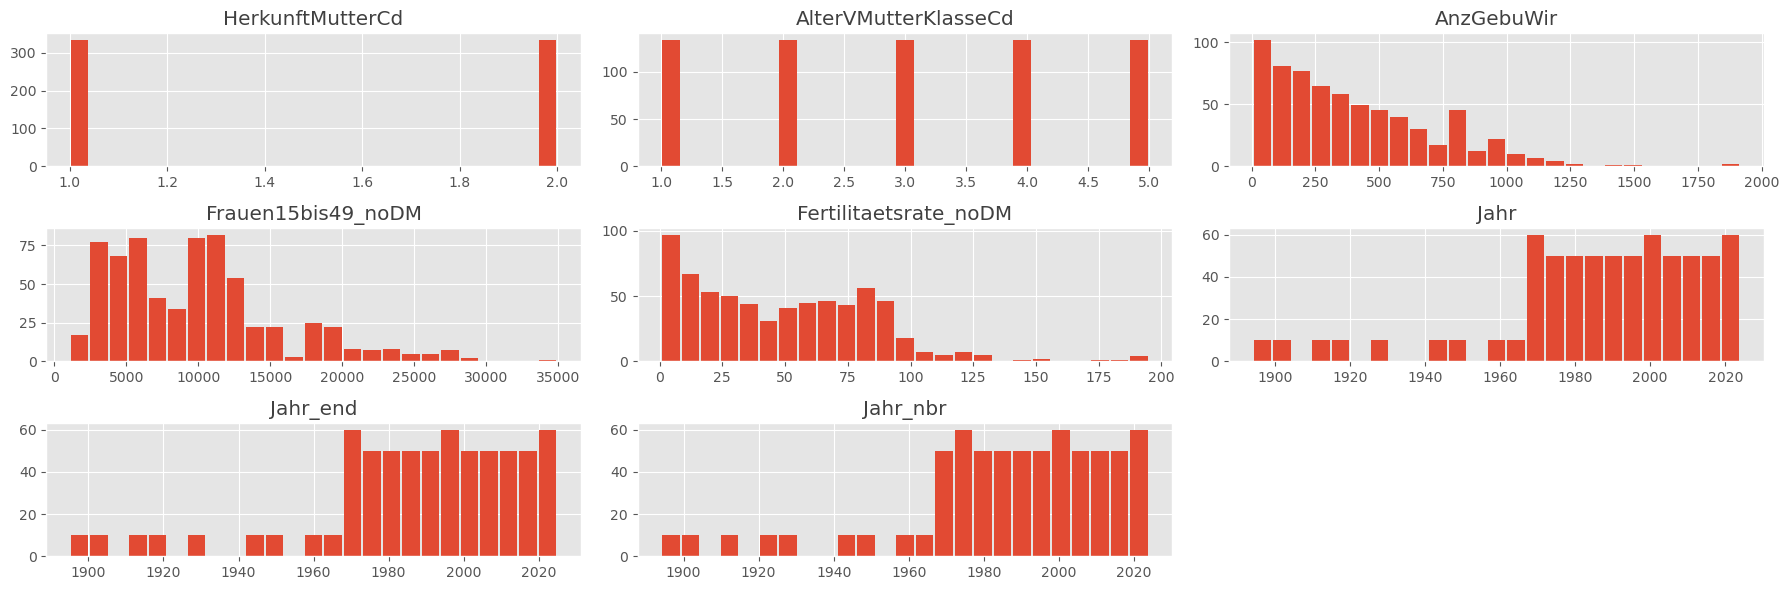

In [123]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [124]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated(keep=False)]
duplicate_rows

,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterKlasseCd,AlterVMutterKlasseLang,Datenquelle_Geburten,Datenquelle_Bestand,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,


### Nullwerte und Missings?

In [125]:
data2betested.isnull().sum()

HerkunftMutterCd          0
HerkunftMutterLang        0
AlterVMutterKlasseCd      0
AlterVMutterKlasseLang    0
Datenquelle_Geburten      0
Datenquelle_Bestand       0
AnzGebuWir                0
Frauen15bis49_noDM        0
Fertilitaetsrate_noDM     0
StichtagDatJahr_str       0
Jahr                      0
Jahr_end                  0
Jahr_nbr                  0
dtype: int64

In den Metadaten beschrieben:
> "Bei den Geburtenzahlen der Jahr 1894, 1900 und 1910 nach Alter der Mutter waren bloss Mittelwerte über mehrere Jahre verfügbar (1894: Mittelwert der Geburten 1893 bis 1895; 1900: Mittelwert der Geburten 1899 bis 1902; 1910: Mittelwert der Geburten 1909 bis 1912). Quelle: Statistisches Jahrbuch der Stadt Zürich, Jahre 1912 und 1913. Die Geburtenzahlen dieser Jahre nach Alter der Mutter wurden auf ganze Zahlen gerunden; die Fertilitätsrate wurde jedoch noch vor dem Runden berechnet."

In [126]:
data2betested[data2betested['Fertilitaetsrate_noDM'].isna()].reset_index() \
    .groupby(['StichtagDatJahr']) \
    .agg(
        mean_AnzGebuWir = ('AnzGebuWir', 'mean'),
        count = ('AnzGebuWir', 'count')
    ).unstack()

Series([], dtype: float64)

In [127]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

Anmerkung Alex: Scheinbar kann man die Daten nicht Gruppieren (es geht um die Fertilitätsrate). Der Schlüssel ist wohl die Spalte Thema. Je nach Thema gibt es verschiedene Untergruppierungen, die dazu kommen (Jahr, Herkunft, Alter).

In [128]:
    #.groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr_nbr', ascending=True) 
agg_jahr.reset_index().head(20)

,StichtagDatJahr,Jahr_nbr,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1894-01-01,1894,3556.4,36447,113.73
1,1900-01-01,1900,4884.8,47289,114.39
2,1910-01-01,1910,4067.3,59330,75.72
3,1920-01-01,1920,3048.0,72228,42.48
4,1930-01-01,1930,3436.0,86923,35.62
5,1941-01-01,1941,4926.0,109470,42.80
6,1950-01-01,1950,5432.0,116075,43.28
7,1960-01-01,1960,6084.0,118029,55.95
8,1966-01-01,1966,5248.0,112544,58.98
9,1967-01-01,1967,5093.0,112099,59.71


In [129]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('HerkunftMutterCd', ascending=False) 
agg_herk.reset_index().head(10)

,HerkunftMutterCd,HerkunftMutterLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,2,Ausländerinnen,105964.9,1883189,56.752537
1,1,Schweizerinnen,158515.6,4742852,39.975821


In [131]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterVMutterKlasseCd', 'AlterVMutterKlasseLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('AlterVMutterKlasseCd', ascending=True) 
agg_age.reset_index().head(11)

,AlterVMutterKlasseCd,AlterVMutterKlasseLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1,15 bis 24,46349.1,1571217,37.959701
1,2,25 bis 29,73614.2,1171994,71.604478
2,3,30 bis 34,83069.6,1127327,75.426866
3,4,35 bis 39,49982.8,998062,49.394030
4,5,40 bis 49,11464.8,1757441,7.435821


In [132]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd',
       'AlterVMutterKlasseLang', 'Datenquelle_Geburten', 'Datenquelle_Bestand', 'AnzGebuWir',
       'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end',
       'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Fertilitätsrate: Thema 4 Fertilität nach Jahr

In [136]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = agg_jahr
myAgg1.reset_index().head(3)


,StichtagDatJahr,Jahr_nbr,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1894-01-01,1894,3556.4,36447,113.73
1,1900-01-01,1900,4884.8,47289,114.39
2,1910-01-01,1910,4067.3,59330,75.72


In [138]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'mean_Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [ ]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'sum_AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Geburten'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [143]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'sum_Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Frauen im gebährfähigen Alter'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Frauen im gebährfähigen Alter nach Jahr, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 3 Fertilität nach Jahr und Herkunft der Mutter

In [146]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr', 'HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr_nbr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,HerkunftMutterCd,HerkunftMutterLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1894-01-01,1894,1,Schweizerinnen,2359.3,26236,102.78
1,1894-01-01,1894,2,Ausländerinnen,1197.1,10211,124.68
2,1900-01-01,1900,1,Schweizerinnen,3140.5,32585,107.04


In [148]:
grafik4 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'mean_Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr und Herkunft, seit "+data_min_date
)
grafik4

alt.LayerChart(...)

In [150]:
grafik5 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'sum_AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Geburten'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr und Herkunft der Mutter, seit "+data_min_date
)
grafik5

alt.LayerChart(...)

In [151]:
grafik6 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'sum_Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Frauen im gebährfähigen Alter'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr und Herkunft, seit "+data_min_date
)
grafik6

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 2 Fertilität nach Jahr und Alter der Mutter

In [153]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr', 'AlterVMutterKlasseCd', 'AlterVMutterKlasseLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr_nbr', ascending=True) 

In [154]:
grafik7 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index()
    ,x = 'StichtagDatJahr:T'
    ,y = 'mean_Fertilitaetsrate_noDM:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "AlterVMutterKlasseLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilität nach Jahr und Alter der Mutter, seit "+data_min_date
)
grafik7

alt.LayerChart(...)

In [152]:
data2betested.columns

Index(['HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd', 'AlterVMutterKlasseLang',
       'Datenquelle_Geburten', 'Datenquelle_Bestand', 'AnzGebuWir', 'Frauen15bis49_noDM',
       'Fertilitaetsrate_noDM', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

#### Entwicklung Fertilitätsrate: Thema 1 Fertilität nach Jahr, Alter und Herkunft der Mutter

#### Faced Grids

In [155]:
data2betested.columns

Index(['HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterKlasseCd', 'AlterVMutterKlasseLang',
       'Datenquelle_Geburten', 'Datenquelle_Bestand', 'AnzGebuWir', 'Frauen15bis49_noDM',
       'Fertilitaetsrate_noDM', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [ ]:
#data2betested[['ThemaCd','ThemaLang']].reset_index(drop=True).drop_duplicates()

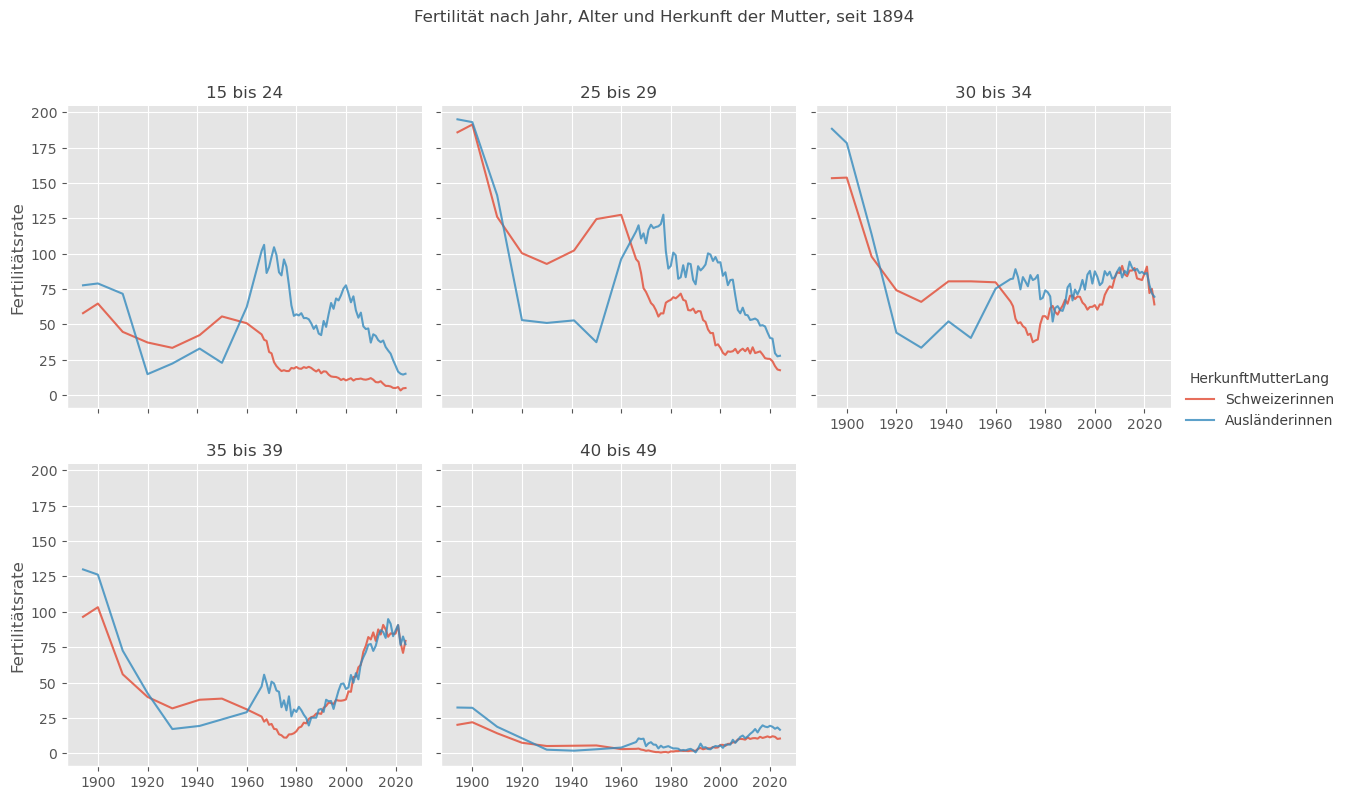

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('AlterVMutterKlasseLang')
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Fertilitaetsrate_noDM"
    ,ylabel= "Fertilitätsrate"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Fertilität nach Jahr, Altersgruppe und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [ ]:
data2betested.columns

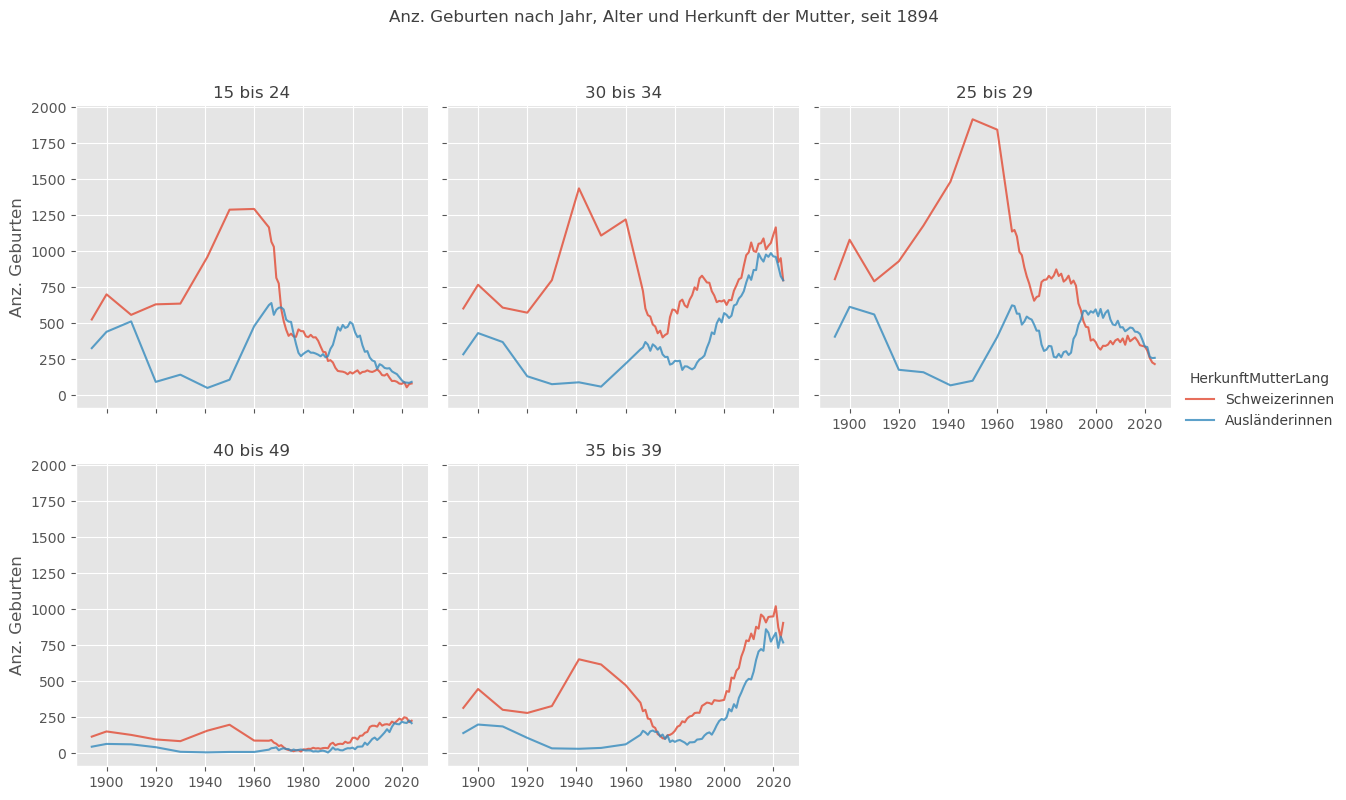

In [158]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index()
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzGebuWir"
    ,ylabel= "Anz. Geburten"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anz. Geburten nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

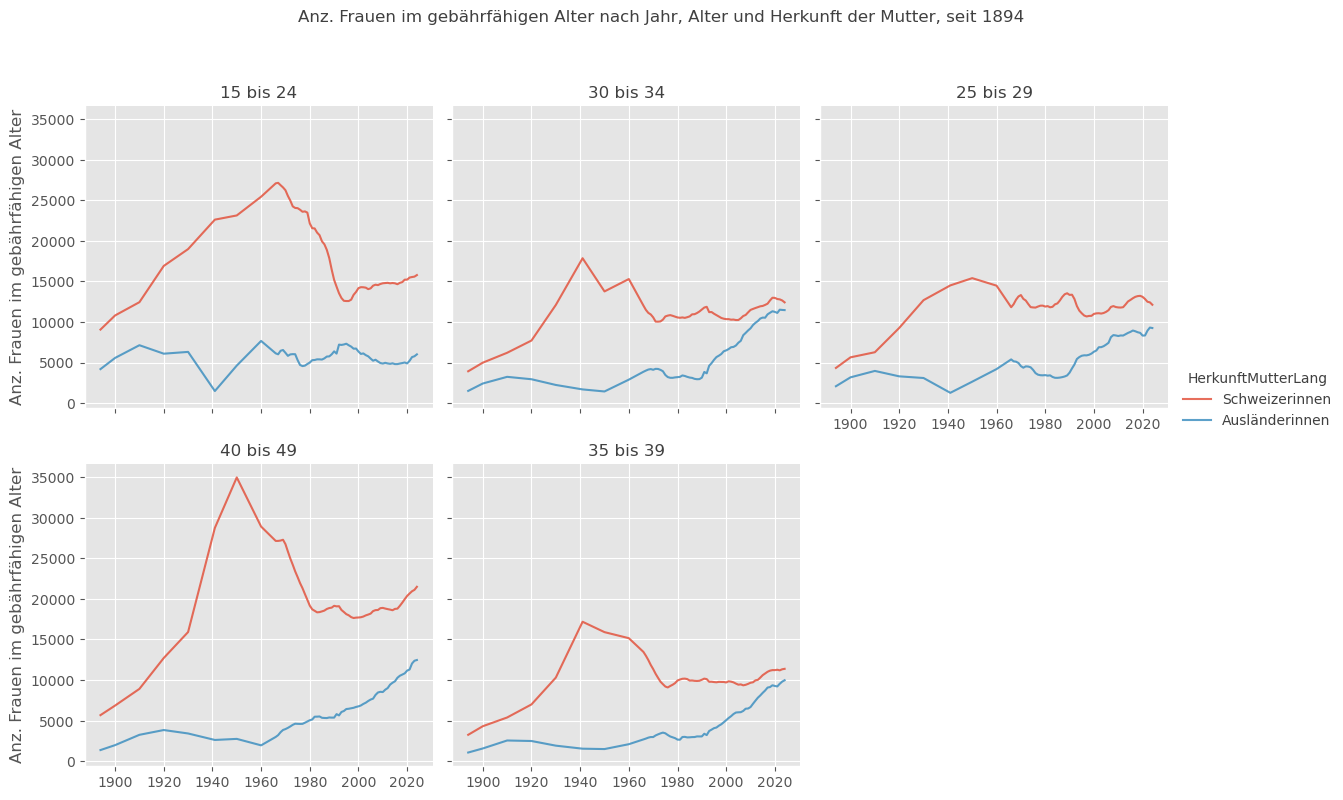

In [159]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index()
    ,col = "AlterVMutterKlasseLang"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Frauen15bis49_noDM"
    ,ylabel= "Anz. Frauen im gebährfähigen Alter"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr, Alter und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [160]:
qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [161]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['AlterVMutterKlasseLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '15 bis 24': '#0017BF', '30 bis 34': '#0072D7', '25 bis 29': '#00A5D2', '40 bis 49': '#5E359A', '35 bis 39': '#BA0062'}


##### Aufschlüssellung im aktuellsten Jahr

In [168]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data_min_date:data_max_date].reset_index()
    ,levels=['HerkunftMutterLang','AlterVMutterKlasseLang']
    ,values="Fertilitaetsrate_noDM"
    ,color="AlterVMutterKlasseLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fertilitätsrate, "+str(data2betested.index.max())
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000024C49E454D0>, 'HerkunftMutterLang', 'AlterVMutterKlasseLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1565&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7BCEAF2600%2D5498%2D413B%2D88AA%2DBEE20C2F4F2F%7D%23InplviewHashceaf2600%2D5498%2D413b%2D88aa%2Dbee20c2f4f2f%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------